# <font color='red'> **NOTICE**

The following code has been written in Google Colab.  Running the code in a different IDE may have differences such as different run time, errors, etc. Please take note of important information:

*   Downloading the data should not be necessary, as the code is written to load it directly from the source website.  However, running the code in a different IDE may require a local download.
*   After installing Renate, Colab will likely prompt a session restart after approximately 3 minutes due to Renate re-installing different versions of certain packages.  This is ok, and after the restart, the code should be able to run through start to finish.

# Miscellaneous Steps (Imports, Device)

## Install Renate

In [43]:
!pip install Renate

## Install UCI repository

In [44]:
!pip install ucimlrepo --quiet

## Import regular packages

In [45]:
# Pytorch packages
import torch
from torch import nn
from torch.optim import SGD, Optimizer
from torch.utils.data import Dataset
from torchmetrics import Accuracy

# Data visualization
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Data pre-processing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Saving/loading files into colab
import requests
from pathlib import Path
import os

## Import Renate packages

In [46]:
from functools import partial
from renate.models import RenateModule
from renate.models.renate_module import RenateWrapper
from renate.data.data_module import RenateDataModule
from renate.updaters.experimental.fine_tuning import FineTuningModelUpdater

## Set Device

In [47]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Experiment: Re-training an MLP Model Traditionally VS with Renate


## Preprocess MLP data

### Load MLP Data

To load the data, we can directly fetch it from the UCI repository using the applicable ID.

In [48]:
# Code copied from official data site
# fetch dataset
single_elder_home_monitoring_gas_and_position = fetch_ucirepo(id=799)

# data (as pandas dataframes)
X = single_elder_home_monitoring_gas_and_position.data.features

In [49]:
X

,timestamp,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
0,2019-11-06 11:37:13.038174+01:00,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0
1,2019-11-06 11:37:32.744996+01:00,19.59,54.23,129.0,563.0,477.0,731.0,649.0,565.0,125.0
2,2019-11-06 11:37:53.018087+01:00,19.63,54.05,128.0,566.0,478.0,732.0,649.0,565.0,125.0
3,2019-11-06 11:38:13.093151+01:00,19.64,53.74,128.0,566.0,478.0,732.0,649.0,565.0,125.0
4,2019-11-06 11:38:33.032832+01:00,19.67,53.53,128.0,569.0,480.0,732.0,650.0,565.0,125.0
...,...,...,...,...,...,...,...,...,...,...
416148,2020-02-13 11:56:53.929978+01:00,20.62,57.75,62.0,518.0,524.0,698.0,642.0,591.0,157.0
416149,2020-02-13 11:57:14.204458+01:00,20.62,57.75,62.0,518.0,524.0,698.0,641.0,591.0,157.0
416150,2020-02-13 11:57:33.983249+01:00,20.62,57.75,62.0,518.0,524.0,698.0,641.0,591.0,157.0
416151,2020-02-13 11:57:54.058349+01:00,20.62,57.74,63.0,518.0,524.0,698.0,641.0,591.0,157.0


### Observe Data Types and Potential Missing Data with .info()

Using .info() can tell us the datatypes of each column, as well as if there are any missing values which would need to be imputed.

In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416153 entries, 0 to 416152
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      416153 non-null  object 
 1   temperature    416153 non-null  float64
 2   humidity       416153 non-null  float64
 3   CO2CosIRValue  416153 non-null  float64
 4   CO2MG811Value  416153 non-null  float64
 5   MOX1           416153 non-null  float64
 6   MOX2           416153 non-null  float64
 7   MOX3           416153 non-null  float64
 8   MOX4           416153 non-null  float64
 9   COValue        416153 non-null  float64
dtypes: float64(9), object(1)
memory usage: 31.8+ MB


We can see that there are no non-null values, so no imputation is needed.  Moreover, all features (except for the timestamp) are in float form, so no encoding of categorical variables is needed.

### Observe Numerical Data Statistics with .describe()


In [51]:
X.describe()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
count,416153.000000,416153.000000,416153.000000,416153.000000,416153.000000,416153.000000,416153.000000,416153.000000,416153.000000
mean,20.115751,52.236446,102.459415,539.086523,500.289413,718.708761,672.788842,609.446752,120.124310
std,2.295836,4.343208,39.026812,34.934361,49.795030,31.296907,36.354293,42.703923,35.992508
min,13.530000,38.160000,21.000000,408.000000,262.000000,514.000000,447.000000,355.000000,74.000000
25%,18.640000,49.050000,76.000000,510.000000,468.000000,703.000000,655.000000,587.000000,103.000000
50%,20.100000,52.310000,105.000000,528.000000,502.000000,719.000000,674.000000,611.000000,113.000000
75%,21.630000,55.640000,117.000000,563.000000,536.000000,738.000000,693.000000,635.000000,128.000000
max,26.140000,69.260000,591.000000,632.000000,626.000000,808.000000,777.000000,727.000000,918.000000


Based on the statistics shown, it can be observed that the target column has values highly skewed left, since the 25th, 50th, and 75th percentile are quite close to each other, and the maximum value is far away.

### Observe Distribution of Output Class with Histogram

In order to understand the class distribution and the approach towards converting the target labels to categorical values, a histogram of the COValue column will be observed.

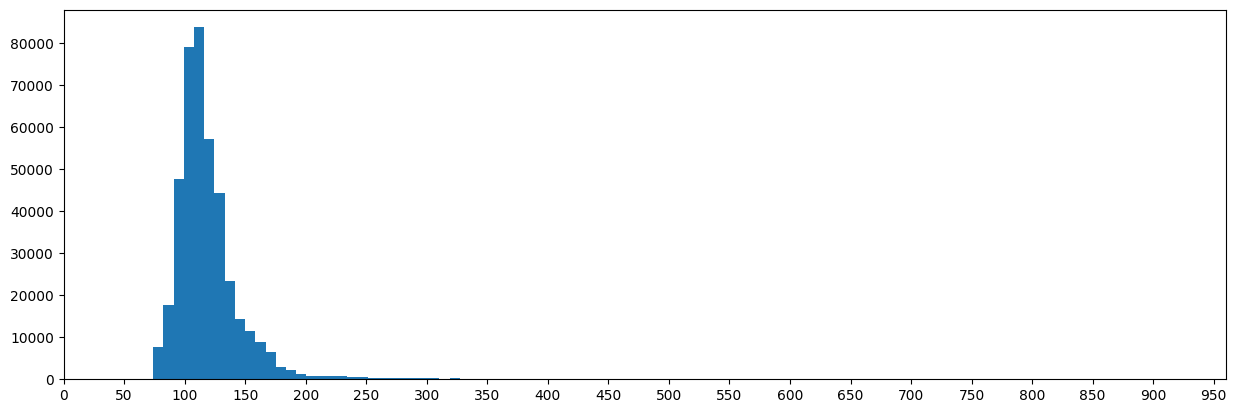

In [52]:
plt.figure(figsize=(15, 4.8))
plt.hist(X["COValue"], bins=100)
plt.xticks(np.arange(0, 1000, 50))
plt.show()

The historgram shows a relatively normal distribution of the output, albeit highly skewed to the left.  We can see that even with a large number of bins, the values are highly concentrated between 100 and 150.  When it comes to turning the target variable into a discrete range, certain classes will likely have a longer range in order to balance the classes.

### Convert Target Variable to Discrete Values

In order to convert the target variable to categorical values, class labels will be determined by which percentile of the data the values fall in.  This is done so that class sizes remain relatively equal and class imbalances are avoided.  The first function defines the upper limits of each class by identifying the percentile splits, with the number of classes set by the user.

In [53]:
# Function: Use np.percentile to determine equal boundaries
def obtain_percentiles(n_desired_classes: int,
                       target: pd.DataFrame):

  # In order to obtain classes of roughly equal size, number of desired classes must be divisible by 100
  if 100%n_desired_classes!=0:
    print("Number of classes cannot be divided on an integer basis.  Consider setting class boundaries manually.")

  else:
    # Create increment size to determine which percentiles to obtain
    increment = int(100/n_desired_classes)
    percentiles = []

    for p in range(increment, 101, increment):
      # Obtain the index of the pth percentile
      percentiles.append(np.percentile(target, p))
    return percentiles

percentiles = obtain_percentiles(10, X["COValue"])
print(percentiles)

[94.0, 101.0, 105.0, 109.0, 113.0, 118.0, 124.0, 133.0, 149.0, 918.0]


The second function takes the upper limits obtained through the first function, and uses them to assign class labels to each data point in the original target column.  Each label is appended to the new target column, which is also added to the data frame within the function.

In [54]:
# Function: For given dataframe, create new column which includes classes
def make_target_column(percentile_list: list[float],
                       data: pd.DataFrame,
                       target: pd.DataFrame,
                       target_name: str):

  # create dictionary with key : value pairs being (class limit) : (class label)
  percentile_dict = dict(zip(percentile_list, range(len(percentile_list))))

  # Instantiate empty list for new class labels and new column in dataframe
  new_labels = []
  data[target_name] = None

  # Function will loop through each percentile value to determine class label
  for x in list(target):
    for key , value in percentile_dict.items():
      # If target value is less than the current key, current value is assigned as class label
      if x <= key:
        new_labels.append(value)
        break

  # Add new target column to data frame
  data[target_name] = new_labels
  return True

make_target_column(percentiles, X, X["COValue"], "COValue_Range")

True

Now that we have created a categorical version of the target column, we can observe the new class distribution.  The expectation is that class sizes will be relatively equal.

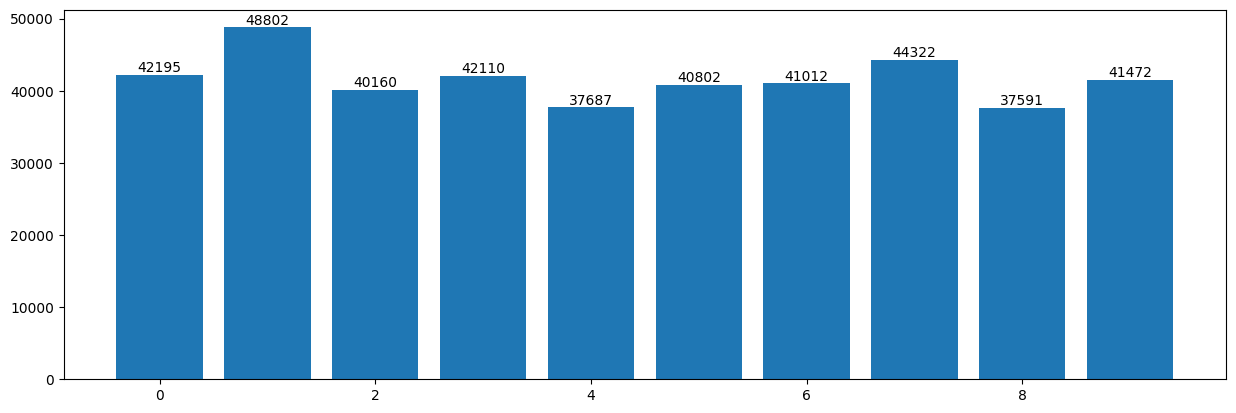

In [55]:
counts = Counter(X["COValue_Range"])
x = list(counts.keys())
heights = list(counts.values())
plt.figure(figsize=(15, 4.8))
bars = plt.bar(x, heights)
plt.bar_label(bars)
plt.show()

The classes are indeed of similar sizes, with some natural imbalance existing.  We can now remove the original target column (along with the timestamp column which is not needed).

In [56]:
X_new = X.drop(["timestamp", "COValue"], axis=1)

###  Split MLP Data into Set 1 and Set 2

Since re-training will take place, the data will now be split into two different sections.  Since the data is originally sequential in nature (due to stats being recorded at different timestamps), the data will be split right down the middle.  Ideally, using set 1 for initial training and set 2 for re-training will hold some resemblance with a real-world scenario where new data would be gathered within a later time period than the initial data.

In [57]:
# Define split index
index_split = X_new.shape[0]//2

# Split data into two sets
X_Set_1 = X_new[:index_split]
X_Set_2 = X_new[index_split:]

# Check that each set has roughly the same number of rows
print(X_Set_1.shape)
print(X_Set_2.shape)

(208076, 9)
(208077, 9)


We can see that each new dataset has a little over 208K samples.

### Preparing MLP Data Sets

The below function is designed to do multiple steps in one round:

*   Split data and labels into train and test sets
*   Split the current training set into train and validation sets
*   If desired, standardize the data for easier computation
*   Convert all data and labels to tensors for use with Pytorch, with data as type float32 and labels as type long (similar to int64)

After separating data and labels for each set, the function is applied to each set with standardization being selected.


In [58]:
# Function for train, validation, test split + standardization (optional)
def train_test_standardize(X, y, test_size, val_size, random_state, device, standardize=False):

  # Initial train/test split
  x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

  # Re-split train data into train/val split
  x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=val_size, random_state=random_state, stratify=y_train)

  # Optional: Standardize data
  if standardize:
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_test = scaler.transform(x_test)

  # Convert data into tensors of type float32, send to device
  x_train = torch.from_numpy(x_train).type(torch.float32).to(device)
  x_val = torch.from_numpy(x_val).type(torch.float32).to(device)
  x_test = torch.from_numpy(x_test).type(torch.float32).to(device)

  # Convert labels into tensors of type long, send to device
  y_train = torch.from_numpy(y_train.to_numpy()).type(torch.long).to(device)
  y_val = torch.from_numpy(y_val.to_numpy()).type(torch.long).to(device)
  y_test = torch.from_numpy(y_test.to_numpy()).type(torch.long).to(device)

  # Return all data
  return x_train, x_val, x_test, y_train, y_val, y_test

In [59]:
# Split Set 1 into X and y
X_Set_1_Data = X_Set_1.drop("COValue_Range", axis=1)
X_Set_1_Labels = X_Set_1["COValue_Range"]

# Split Set 1 into all data partitions
Set_1 = train_test_standardize(X_Set_1_Data, X_Set_1_Labels, test_size=0.2, val_size=0.1, random_state=42, device=device, standardize=True)
X_Train_1, X_Val_1, X_Test_1, y_Train_1, y_Val_1, y_Test_1 = Set_1

In [60]:
# Split Set 2 into X and y
X_Set_2_Data = X_Set_2.drop("COValue_Range", axis=1)
X_Set_2_Labels = X_Set_2["COValue_Range"]

# Split Set 2 into all data partitions
Set_2 = train_test_standardize(X_Set_2_Data, X_Set_2_Labels, test_size=0.2, val_size=0.1, random_state=42, device=device, standardize=True)
X_Train_2, X_Val_2, X_Test_2, y_Train_2, y_Val_2, y_Test_2 = Set_2

## Train MLP Model on First Iteration

### Create MLP Model Class

A structure for an MLP model can now be created.  The structure will remain relatively simple, containing two hidden layers.

In [61]:
# MLP Model
class MLPModel(nn.Module):
  def __init__(self, input_shape, layer_1_nodes, layer_2_nodes, output_shape):
    super().__init__()
    self.mlp_model = nn.Sequential(nn.Linear(input_shape, layer_1_nodes),
                                   nn.Linear(layer_1_nodes, layer_2_nodes),
                                   nn.Linear(layer_2_nodes, output_shape))

  def forward(self, x):
    return self.mlp_model(x)

### Create Training and Testing Loops

The training loop is designed to calculate both loss and accuracy for both training and validation.  If the final epoch has been reached, the final metrics will be printed.  The testing function does not loop through epochs, but performs a single round of predictions and returns loss and accuracy functions.

In [62]:
# Training Loop
def train_loop(model, x_train, x_val, y_train, y_val, epochs, loss_fn, accuracy_fn, optimizer):

  # Loop through each epoch
  for epoch in range(epochs):

    # Set model to train mode
    model.train()

    # Obtain training predictions
    y_logits = model(x_train)
    y_preds = torch.argmax(y_logits, dim=1)

    # Calculate training loss and accuracy
    train_loss = loss_fn(y_logits, y_train)
    train_acc = accuracy_fn(y_train, y_preds)

    # Perform back propagation
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Set model to evaluation mode
    model.eval()
    with torch.inference_mode():

      # Obtain validation predictions
      val_logits = model(x_val)
      val_pred = torch.argmax(val_logits, dim=1)

      # Calculate validation loss and accuracy
      val_loss = loss_fn(val_logits, y_val)
      val_acc = accuracy_fn(y_val, val_pred)

  # Print out final values for training/validation loss/accuracy
  if epoch==(epochs-1):
    print("Final Training Loss:", train_loss.item())
    print("Final Training Accuracy:", train_acc.item())
    print("Final Validation Loss:", val_loss.item())
    print("Final Validation Accuracy:", val_acc.item())

# Testing function
def test_function(model, x_test, y_test, loss_fn, accuracy_fn):
  model.eval()
  with torch.inference_mode():
    test_logits = model(x_test)
    test_pred = torch.argmax(test_logits, dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)
    print("Testing Loss:", test_loss.item())
    print("Testing Accuracy:", test_acc)

### Instantiate Model, Loss Function, Accuracy Function, and Optimizer

As defined earlier, the number of classes (and the dimension of the model's output layer) is 10.  Since this is a classification problem, the loss will be Cross Entropy.  The optimizer will be Stochastic Gradient Descent, and regular accuracy will be used.

In [63]:
# Define number of classes
num_classes_mlp = 10

# Instantiate model
mlp_model_1 = MLPModel(X_Train_1.shape[1], 128, 64, num_classes_mlp).to(device)

# Loss Function
loss_fn_mlp = nn.CrossEntropyLoss()

# Optimizer
optimizer_mlp = SGD(params=mlp_model_1.parameters(), lr=0.01)

# Accuracy
accuracy_mlp = Accuracy(task="multiclass", num_classes=num_classes_mlp).to(device)

### Train MLP Model & Make Predictions

The MLP model is first trained on Set 1 of the data, before being evaluated on the testing data.  torch.manual_seed() is used for reproducible results.

In [64]:
torch.manual_seed(42)
train_loop(mlp_model_1, x_train=X_Train_1, x_val=X_Val_1,
           y_train=y_Train_1, y_val=y_Val_1, epochs=50,
           loss_fn=loss_fn_mlp, accuracy_fn=accuracy_mlp, optimizer=optimizer_mlp)

Final Training Loss: 2.0336806774139404
Final Training Accuracy: 0.2559707462787628
Final Validation Loss: 2.031871795654297
Final Validation Accuracy: 0.2551363706588745


In [65]:
torch.manual_seed(42)
test_function(mlp_model_1, x_test=X_Test_1, y_test=y_Test_1,
              loss_fn=loss_fn_mlp, accuracy_fn=accuracy_mlp)

Testing Loss: 2.033334255218506
Testing Accuracy: tensor(0.2566)


We can see that for training, validation, and testing, the metrics are unfortunately unsatistfying.  Loss values are higher than expected, and accuracy values are much lower than expected.

## Re-train MLP model Using the Traditional Approach (Second Training Iteration)

The first example of re-training the MLP model will be to save the trained weights, load them into a new model, and repeat the training process with Set 2 of the data, exactly as we did with Set 1.  This method of re-training a model is very prone to catastrophic forgetting.

### Save Model

In order to save the model weights, a directory is created for saving models.  Once created, .state_dict() is used to obtain the weights of the model and save them in a .pth file.

In [66]:
# Create directory for models
model_path = Path("Models")
model_path.mkdir(parents=True, exist_ok=True)

# Save model
model_name_mlp = "mlp_model.pth"
model_save_path_mlp = model_path/model_name_mlp
torch.save(obj=mlp_model_1.state_dict(), f=model_save_path_mlp)

### Re-load Model

In order to create a new model using the weights of the previous model, we first have to create a new instance of the MLP model.  Once done, we can use .load_state_dict() to load the weights stored in the file created above.

In [67]:
mlp_model_2 = MLPModel(X_Train_2.shape[1], 128, 64, num_classes_mlp).to(device)
mlp_model_2.load_state_dict(torch.load(f=model_save_path_mlp))

<All keys matched successfully>

### Re-train Model with Loaded Weights & Make Predictions

The training process will now be performed again, the same way it was performed the first time.

In [68]:
torch.manual_seed(42)
train_loop(mlp_model_2, x_train=X_Train_2, x_val=X_Val_2,
           y_train=y_Train_2, y_val=y_Val_2, epochs=50,
           loss_fn=loss_fn_mlp, accuracy_fn=accuracy_mlp, optimizer=optimizer_mlp)

Final Training Loss: 2.0720131397247314
Final Training Accuracy: 0.19849947094917297
Final Validation Loss: 2.075009822845459
Final Validation Accuracy: 0.2015378177165985


In [69]:
torch.manual_seed(42)
test_function(mlp_model_2, x_test=X_Test_2, y_test=y_Test_2,
              loss_fn=loss_fn_mlp, accuracy_fn=accuracy_mlp)

Testing Loss: 2.0715701580047607
Testing Accuracy: tensor(0.2001)


The values for the metrics do not seem to be that much different from the first training round.  While low accuracy was expected this time, the similar values may indicate that catastrophic forgetting did not take place in this instance.

## Re-train MLP Model Using Renate

### Create Renate Model

To create a Renate model, we can instantiate an MLP model the same way as before, loading the weights from the first trained model.  After doing this, RenateWrapper() is used to turn it into a Renate model.

In [70]:
mlp_model_3 = MLPModel(X_Train_2.shape[1], 128, 64, num_classes_mlp)
mlp_model_3.load_state_dict(torch.load(f=model_save_path_mlp))
mlp_renate = RenateWrapper(mlp_model_3)

### Creating a Renate Dataset

In order to create a Renate datset, the existing Set 2 data will first be converted into an official Pytorch dataset.  This can be done in a simple manner, subclassing torch.utils.data.Dataset.  To do this, we will have to override the len() and getitem() functions usually defined in a Dataset class.

In [71]:
# Pytorch dataset
class PytorchDataset(Dataset):
  def __init__(self, data, labels):
      self.data = data
      self.labels = labels

  def __len__(self):
      return len(self.data)

  def __getitem__(self, idx):
      return self.data[idx], self.labels[idx]

# Create training, validation, and test datasets
train_dataset_mlp_r = PytorchDataset(X_Train_2, y_Train_2)
val_dataset_mlp_r = PytorchDataset(X_Train_2, y_Train_2)
test_dataset_mlp_r = PytorchDataset(X_Train_2, y_Train_2)

We can now create an official Renate dataset which subclasses RenateDataModule.  Usually, a RenateDataModule includes 5 functions:
*   prepare_data(): Downloads the data
*   setup(): Creates train, validation, and test data
*   train_data(), val_data(), test_data(): Returns applicable data partitions

We have already had our data loaded and preprocessed.  Therefore, these two functions are not necessarily needed.  However, Renate will throw an error if a data_path argument is not included, so it is passed in the super() function to satisfy the requirements of RenateDataModule.


In [72]:
class RenateDataMLP(RenateDataModule):
    def __init__(self, data_path, train_data, val_data, test_data):
        super().__init__(data_path=data_path)
        self.data_path = data_path
        self.train_data = train_data
        self.val_data = val_data
        self.test_data = test_data

    def prepare_data(self):
      pass

    def setup(self):
      pass

    def train_data(self):
      return self.train_data

    def val_data(self):
      return self.val_data

    def test_data(self):
      return self.test_data

The data module can now be instantiated.  We will also pass the .prepare_data() and .setup() functions in case it is required by Renate.

In [73]:
# Initialize data module
data_module_mlp = RenateDataMLP(data_path="/dummy/path", train_data=train_dataset_mlp_r,
                            val_data=val_dataset_mlp_r, test_data=test_dataset_mlp_r)

# Prepare and setup data
data_module_mlp.prepare_data()
data_module_mlp.setup()

### Define Renate Loss Function and Optimizer

The loss function and optimizer will be similar to before, although we pass reduction="none" into the loss function as this is required by Renate.

In [74]:
# Define loss function
loss_fn_mlp_r = torch.nn.CrossEntropyLoss(reduction="none")

# Define optimizer
optimizer_mlp_r = partial(SGD, lr=0.01)

### Update Model with Renate

We can now re-train the model.  While various methods for re-training are available within Renate, the FineTuningModelUpdater() class is suitable for our problem which only involves one new dataset.  The main parameters consist of:
*   **model:** The model to be updated
*   **loss_fn:** The applicable loss function
*   **optimizer:** The applicable optimizer
*   **metric:** The metric which is monitored to determine a new checkpoint or early stopping
  *  Note that this is not a setting to define the desired metrics to be reported.
*   **batch_size:** Batch size for training
*   **max_epochs:** Upper limit for number of epochs to be performed
*   **input_state_folder:** Folder to store files for current state
*   **output_state_folder:** Folder to store files for next state
  *  Note that both input and output state folders are not required to be defined.  As a matter of fact, it is better to not define them unless needed since the outputted files will quickly take up storage space.

Other parameters include but are not limited to:
*   **train/test_transform, train/test target transform** (usually for image data)
*   **early_stopping_enabled** (if true, will do early stopping)
*   **gradient_clip_val/gradient_clip_algorithm** (for gradient clipping)

Once the updater is instantiated, we can pass the training and validation data to its .update() function to re-train the model.

In [75]:
# Instantiate instance of model updater
updater_mlp = FineTuningModelUpdater(
    model=mlp_renate,
    loss_fn=loss_fn_mlp_r,
    optimizer=optimizer_mlp_r,
    metric=None,
    batch_size=32,
    max_epochs=50,
    input_state_folder=None,
    output_state_folder=None)

# Update model
updater_mlp.update(data_module_mlp.train_data,
                   data_module_mlp.val_data)

INFO:renate.updaters.model_updater:No location for current updater state provided. Updating will start from scratch.
INFO:renate.updaters.model_updater:No location for next updater state provided. No state will be stored.
/usr/local/lib/python3.10/dist-packages/renate/utils/distributed_strategies.py:40: UserWarning: With devices=1, strategy is ignored. But got ddp.
  warnings.warn(f"With devices=1, strategy is ignored. But got {strategy_name}.")
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:613: UserWarning: Checkpoint directory /root/.renate/renate_working_dir/lightning_logs/version_1/checkpoints exists and is not empty.
  rank_ze

[tune-metric]: {"train_base_loss": 1.6574745178222656, "train_loss": 1.6574745178222656, "val_loss": 1.6249043941497803, "total_training_time": 0.0, "peak_memory_usage": 0, "trainable_params": 10058, "total_params": 10058, "step": 0, "epoch": 1, "st_worker_timestamp": 1736629427.816365, "st_worker_time": 21.455992986000183, "st_worker_iter": 0}
[tune-metric]: {"train_base_loss": 1.6192079782485962, "train_loss": 1.6192079782485962, "val_loss": 1.615602970123291, "total_training_time": 21.353516101837158, "peak_memory_usage": 0, "trainable_params": 10058, "total_params": 10058, "step": 1, "epoch": 2, "st_worker_timestamp": 1736629448.315777, "st_worker_time": 41.955404184000145, "st_worker_iter": 1}
[tune-metric]: {"train_base_loss": 1.6130086183547974, "train_loss": 1.6130086183547974, "val_loss": 1.6093631982803345, "total_training_time": 41.84535884857178, "peak_memory_usage": 0, "trainable_params": 10058, "total_params": 10058, "step": 2, "epoch": 3, "st_worker_timestamp": 173662947

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


RenateWrapper(
  (_model): MLPModel(
    (mlp_model): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=10, bias=True)
    )
  )
)

From the initial results, we can see that the training and validation loss are slightly lower than the previous results.  Let's now save the model weights in our Models file, and reload them to make test predictions.

In [76]:
model_name_mlp_r = "mlp_r_model.pth"
model_save_path_mlp_r = model_path/model_name_mlp_r
torch.save(obj=mlp_renate.state_dict(), f=model_save_path_mlp_r)

In [77]:
mlp_renate_2 = RenateWrapper(MLPModel(X_Train_2.shape[1], 128, 64, num_classes_mlp).to(device))
mlp_renate_2.load_state_dict(torch.load(f=model_save_path_mlp_r))

<All keys matched successfully>

In [78]:
test_function(mlp_renate_2, x_test=X_Test_2, y_test=y_Test_2, loss_fn=loss_fn_mlp, accuracy_fn=accuracy_mlp)

Testing Loss: 1.6099156141281128
Testing Accuracy: tensor(0.4011)


While the test accuracy is still low, it is quite an improvement from the previous results.  This can suggest that Renate is indeed effective at re-training a model.